# STEP 1 — Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns',None)

# STEP 2 — Load Dataset

In [3]:
df = pd.read_csv("jewellery_purchase_messy_383_records.csv")
df.head()

,Transaction_ID,Purchase_Date,Customer_ID,Brand,Category,Product,Festival,City,Quantity,Original_Price,Discount_Percent,Final_Price,Rating,Payment_Mode,Sales_Channel,Return_Status,Making_Charges
0,TXN0001,04-30-2025,CUST155,PC Jeweller,gold,Gold Necklace,Diwali,Chennai,1.0,44868,18.0,36791,3.3,Credit Card,online,Yes,12149
1,TXN0002,2025-10-02,CUST097,Malabar,PLATINUM,Platinum Chain,Akshaya Tritiya,Mumbai,1.0,188263,12.0,NaN,4.7,Debit Card,Online,No,4309
2,TXN0003,2025-05-06,CUST119,JOYALUKKAS,DIAMOND,Diamond Earrings,Akshaya Tritiya,Hyderabad,1.0,164973,5.0,156724,4.3,UPI,NaN,No,14145
3,TXN0004,05-15-2025,CUST150,MALABAR,Silver,Silver Chain,Akshaya Tritiya,Mumbai,1.0,6681,8.0,6146,3.6,Credit Card,NaN,NaN,14833
4,TXN0005,31/05/2025,CUST041,JOYALUKKAS,Gold,Gold Bangles,Wedding Season,Delhi,1.0,21009,12.0,18487,4.6,Debit Card,NaN,NaN,17635


# STEP 3 — Basic Inspection

In [4]:
# First 5 records 
df.head()

,Transaction_ID,Purchase_Date,Customer_ID,Brand,Category,Product,Festival,City,Quantity,Original_Price,Discount_Percent,Final_Price,Rating,Payment_Mode,Sales_Channel,Return_Status,Making_Charges
0,TXN0001,04-30-2025,CUST155,PC Jeweller,gold,Gold Necklace,Diwali,Chennai,1.0,44868,18.0,36791,3.3,Credit Card,online,Yes,12149
1,TXN0002,2025-10-02,CUST097,Malabar,PLATINUM,Platinum Chain,Akshaya Tritiya,Mumbai,1.0,188263,12.0,NaN,4.7,Debit Card,Online,No,4309
2,TXN0003,2025-05-06,CUST119,JOYALUKKAS,DIAMOND,Diamond Earrings,Akshaya Tritiya,Hyderabad,1.0,164973,5.0,156724,4.3,UPI,NaN,No,14145
3,TXN0004,05-15-2025,CUST150,MALABAR,Silver,Silver Chain,Akshaya Tritiya,Mumbai,1.0,6681,8.0,6146,3.6,Credit Card,NaN,NaN,14833
4,TXN0005,31/05/2025,CUST041,JOYALUKKAS,Gold,Gold Bangles,Wedding Season,Delhi,1.0,21009,12.0,18487,4.6,Debit Card,NaN,NaN,17635


In [5]:
# last 5 records
df.tail()

,Transaction_ID,Purchase_Date,Customer_ID,Brand,Category,Product,Festival,City,Quantity,Original_Price,Discount_Percent,Final_Price,Rating,Payment_Mode,Sales_Channel,Return_Status,Making_Charges
378,TXN0036,29/04/2025,CUST164,Malabar Gold,Diamond,Diamond Necklace,Akshaya Tritiya,NaN,1.0,225563,10.0,203006,4.1,Net Banking,Store,NaN,14903
379,TXN0141,2025-11-10,CUST003,pc jeweller,Silver,Silver Anklet,Diwali,Pune,2.0,13329,18.0,10929,NaN,Credit Card,App,NaN,13407
380,TXN0208,06/07/2025,CUST047,PCJeweller,DIAMOND,Diamond Bracelet,Diwali,NaN,1.0,271701,8.0,249964,4.7,Net Banking,Offline,no,4372
381,TXN0042,2025-06-15,CUST045,Malabar Gold,Platinum,Platinum Bracelet,NaN,Chennai,1.0,33895,15.0,28810,NaN,Net Banking,Offline,no,2420
382,TXN0153,2025-10-12,CUST032,CaratLane,Gold,Gold Bangles,Regular Sale,Delhi,1.0,"₹95,326",15.0,81027,4.9,Credit Card,Website,NaN,"17,795"


In [6]:
# shape of dataset
df.shape

(383, 17)

In [7]:
# col names 
df.columns

Index(['Transaction_ID', 'Purchase_Date', 'Customer_ID', 'Brand', 'Category',
       'Product', 'Festival', 'City', 'Quantity', 'Original_Price',
       'Discount_Percent', 'Final_Price', 'Rating', 'Payment_Mode',
       'Sales_Channel', 'Return_Status', 'Making_Charges'],
      dtype='object')

In [8]:
# dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 383 entries, 0 to 382
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction_ID    383 non-null    object 
 1   Purchase_Date     383 non-null    object 
 2   Customer_ID       383 non-null    object 
 3   Brand             383 non-null    object 
 4   Category          383 non-null    object 
 5   Product           383 non-null    object 
 6   Festival          368 non-null    object 
 7   City              373 non-null    object 
 8   Quantity          367 non-null    float64
 9   Original_Price    357 non-null    object 
 10  Discount_Percent  369 non-null    float64
 11  Final_Price       361 non-null    object 
 12  Rating            351 non-null    float64
 13  Payment_Mode      325 non-null    object 
 14  Sales_Channel     320 non-null    object 
 15  Return_Status     308 non-null    object 
 16  Making_Charges    362 non-null    object 
dt

In [9]:
# statistical summary
df.describe(include='all')

,Transaction_ID,Purchase_Date,Customer_ID,Brand,Category,Product,Festival,City,Quantity,Original_Price,Discount_Percent,Final_Price,Rating,Payment_Mode,Sales_Channel,Return_Status,Making_Charges
count,383,383,383,383,383,383,368,373,367.000000,357,369.000000,361,351.000000,325,320,308,362
unique,365,305,150,31,16,16,14,17,NaN,327,NaN,336,NaN,6,6,3,330
top,TXN0028,12-31-2025,CUST035,JOYALUKKAS,Gold,Gold Bangles,Diwali,Mumbai,NaN,unknown,NaN,unknown,NaN,Cash,Store,No,unknown
freq,2,3,8,25,55,41,101,68,NaN,14,NaN,9,NaN,65,71,186,13
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.245232,NaN,11.303523,NaN,4.158405,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.490147,NaN,6.141450,NaN,0.575084,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,0.000000,NaN,3.200000,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,8.000000,NaN,3.650000,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,12.000000,NaN,4.100000,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,18.000000,NaN,4.600000,NaN,NaN,NaN,NaN


# STEP 4 — Data Quality Check

In [10]:
# missing values
df.isnull().sum()

# Insight:
# The dataset has moderate missing values, but key sales and customer information
# is complete, indicating good data availability for business analysis after cleaning.

Transaction_ID       0
Purchase_Date        0
Customer_ID          0
Brand                0
Category             0
Product              0
Festival            15
City                10
Quantity            16
Original_Price      26
Discount_Percent    14
Final_Price         22
Rating              32
Payment_Mode        58
Sales_Channel       63
Return_Status       75
Making_Charges      21
dtype: int64

In [11]:
# missing %
(df.isnull().sum()/len(df))*100

Transaction_ID       0.000000
Purchase_Date        0.000000
Customer_ID          0.000000
Brand                0.000000
Category             0.000000
Product              0.000000
Festival             3.916449
City                 2.610966
Quantity             4.177546
Original_Price       6.788512
Discount_Percent     3.655352
Final_Price          5.744125
Rating               8.355091
Payment_Mode        15.143603
Sales_Channel       16.449086
Return_Status       19.582245
Making_Charges       5.483029
dtype: float64

In [12]:
# duplicated records
df.duplicated().sum()

# Insight :

# There are 18 duplicate records found 

np.int64(18)

In [13]:
df[df.duplicated()]

# Insight
# • Certain transactions appear multiple times.
# • These records may have been entered repeatedly by mistake.
# • Duplicate entries do not represent actual customer purchases.

# Actions 
# • Remove duplicate transactions before reporting.
# • Introduce transaction ID validation checks.
# • Ensure accurate sales and revenue tracking.

,Transaction_ID,Purchase_Date,Customer_ID,Brand,Category,Product,Festival,City,Quantity,Original_Price,Discount_Percent,Final_Price,Rating,Payment_Mode,Sales_Channel,Return_Status,Making_Charges
365,TXN0243,2025-03-01,CUST005,MALABAR,GOLD,Gold Chain,Wedding Season,Chennai,2.0,164448,5.0,156225,4.0,upi,Store,No,4886
366,TXN0110,02-09-2025,CUST096,Malabar,Gold,Gold Ring,Wedding Season,Pune,1.0,127935,18.0,104906,4.8,NaN,Store,No,3830
367,TXN0028,2025-03-22,CUST105,CARATLANE,Gold,Gold Ring,Dhanteras,Chennai,1.0,73318,8.0,67452,3.6,NaN,NaN,NaN,20326
368,TXN0109,29/01/2025,CUST146,tanishq,DIAMOND,Diamond Ring,Diwali,Mumbai,1.0,"₹299,650",5.0,NaN,4.1,UPI,Offline,No,16458
369,TXN0012,2025-12-06,CUST035,Malabar Gold,Gold,Gold Chain,Diwali,Delhi,1.0,97303,0.0,97303,4.4,NaN,Store,no,17008
370,TXN0351,01/04/2025,CUST156,joyalukkas,Gold,Gold Chain,NaN,Chennai,1.0,67508,12.0,59407,3.2,NaN,Online,no,4267
371,TXN0217,2025-08-11,CUST074,JOYALUKKAS,Diamond,Diamond Bracelet,Regular Sale,Delhi,1.0,NaN,18.0,183781,4.1,Cash,App,NaN,9932
372,TXN0139,2025-06-25,CUST030,TANISHQ,Gold,Gold Ring,Akshaya Tritiya,Chennai,1.0,62698,12.0,55174,4.8,UPI,Offline,NaN,NaN
373,TXN0130,12-31-2025,CUST165,BlueStone,Platinum,Platinum Bracelet,Akshaya Tritiya,Chennai,2.0,88659,12.0,78019,4.3,Net Banking,Online,No,17761
374,TXN0326,2025-11-04,CUST165,PCJeweller,Diamond,Diamond Ring,Regular Sale,Delhi,1.0,72417,10.0,65175,4.9,Credit Card,Offline,No,4790


# STEP 6 - Remove duplicates

In [14]:
df = df.drop_duplicates()

# Insight:
# • Duplicate transaction records were removed from the dataset.
# • This ensures each purchase is counted only once.
# • Revenue, sales volume and customer analysis will now be more accurate.

# Action:
# • Implement transaction ID validation to prevent duplicate billing.
# • Schedule regular data quality checks to identify duplicate entries.
# • Maintain clean transaction records for reliable business reporting.

# 6.2 Standardize Brand Names

In [15]:
df['Brand'] = df['Brand'].str.strip().str.title()

df['Brand'] = df['Brand'].replace({
    'Tanishq Jewels':'Tanishq',
    'Malabar Gold':'Malabar',
    'Kalyan Jewellers':'Kalyan',
    'Blue Stone':'Bluestone'
})

df['Brand'].unique()

# Insight:
# • Same brands were stored under multiple names.
# • Standardizing brand names improves reporting accuracy.
# • Brand performance can now be measured correctly.

# Action:
# • Create a master brand list in the transaction system.
# • Use dropdown selections instead of manual text entry.

C:\Users\Karishma\AppData\Local\Temp\ipykernel_23760\2540583389.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Brand'] = df['Brand'].str.strip().str.title()
C:\Users\Karishma\AppData\Local\Temp\ipykernel_23760\2540583389.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Brand'] = df['Brand'].replace({


array(['Pc Jeweller', 'Malabar', 'Joyalukkas', 'Bluestone', 'Tanishq',
       'Carat Lane', 'Caratlane', 'Kalyan', 'Pcjeweller'], dtype=object)

# 6.3 Standardize Category Names

In [16]:
df['Category'] = df['Category'].str.strip().str.title()

df['Category'].unique()

# Insight:
# • Category names had inconsistent formatting.
# • Gold, Diamond, Silver and Platinum categories are now standardized.
# • Product-level analysis will be more reliable.

# Action:
# • Maintain predefined category values.
# • Restrict free-text category entry during billing.

C:\Users\Karishma\AppData\Local\Temp\ipykernel_23760\3206843708.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Category'] = df['Category'].str.strip().str.title()


array(['Gold', 'Platinum', 'Diamond', 'Silver'], dtype=object)

# 6.4 Standardize Festival Names

In [17]:
df['Festival'] = df['Festival'].str.strip().str.title()

df['Festival'].unique()

# Insight:
# • Festival names contained formatting inconsistencies.
# • Festival-based sales analysis is now more accurate.
# • Seasonal demand patterns can be measured properly.

# Action:
# • Standardize campaign and festival naming conventions.
# • Use fixed festival tags in marketing systems.

C:\Users\Karishma\AppData\Local\Temp\ipykernel_23760\3018086359.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Festival'] = df['Festival'].str.strip().str.title()


array(['Diwali', 'Akshaya Tritiya', 'Wedding Season', nan, 'Regular Sale',
       'Dhanteras'], dtype=object)

# 6.5 Standardize City Names

In [18]:
df['City'] = df['City'].str.strip().str.title()

df['City'].unique()

# Insight:
# • City names were stored in multiple formats.
# • Regional sales analysis is now cleaner.
# • Location-based customer trends can be identified accurately.

# Action:
# • Use location master tables.
# • Avoid manual city name entry wherever possible.

C:\Users\Karishma\AppData\Local\Temp\ipykernel_23760\1040575604.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['City'] = df['City'].str.strip().str.title()


array(['Chennai', 'Mumbai', 'Hyderabad', 'Delhi', 'Pune', 'Bangalore',
       nan], dtype=object)

# 6.6 Clean Price Columns

In [19]:
price_cols = ['Original_Price','Final_Price','Making_Charges']

for col in price_cols:
    
    df[col] = df[col].astype(str)
    
    df[col] = df[col].str.replace('₹','',regex=False)
    
    df[col] = df[col].str.replace(',','',regex=False)
    
    df[col] = df[col].replace('unknown',np.nan)
    
    df[col] = pd.to_numeric(df[col],errors='coerce')

df[price_cols].head()

# Insight:
# • Currency symbols, commas and invalid values were present.
# • Price columns are now converted into numerical format.
# • Revenue and pricing analysis can now be performed correctly.

# Action:
# • Store monetary values in numeric format at source systems.
# • Avoid manual price entry whenever possible.

C:\Users\Karishma\AppData\Local\Temp\ipykernel_23760\3281690311.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = df[col].astype(str)
C:\Users\Karishma\AppData\Local\Temp\ipykernel_23760\3281690311.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = df[col].str.replace('₹','',regex=False)
C:\Users\Karishma\AppData\Local\Temp\ipykernel_23760\3281690311.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer

,Original_Price,Final_Price,Making_Charges
0,44868.0,36791.0,12149.0
1,188263.0,NaN,4309.0
2,164973.0,156724.0,14145.0
3,6681.0,6146.0,14833.0
4,21009.0,18487.0,17635.0


# 6.7 Clean Rating Column

In [20]:
df['Rating'] = pd.to_numeric(df['Rating'],errors='coerce')

df.loc[(df['Rating'] > 5) | (df['Rating'] < 1),'Rating'] = np.nan

# Insight:
# • Some ratings exceeded the valid 1–5 range.
# • Invalid customer feedback records were identified.
# • Rating analysis is now more trustworthy.

# Action:
# • Apply rating validation rules in feedback forms.
# • Restrict customer ratings between 1 and 5.

C:\Users\Karishma\AppData\Local\Temp\ipykernel_23760\2383608557.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Rating'] = pd.to_numeric(df['Rating'],errors='coerce')


# 6.8 Convert Date Format

In [21]:
df['Purchase_Date'] = pd.to_datetime(df['Purchase_Date'],errors='coerce')

df['Purchase_Date'].head()

# Insight:
# • Multiple date formats existed in the dataset.
# • Dates are now standardized into a common format.
# • Time-based sales analysis can now be performed.

# Action:
# • Follow a single date format across all systems.
# • Standardize transaction date storage.

C:\Users\Karishma\AppData\Local\Temp\ipykernel_23760\3576321863.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Purchase_Date'] = pd.to_datetime(df['Purchase_Date'],errors='coerce')


0   2025-04-30
1          NaT
2          NaT
3   2025-05-15
4          NaT
Name: Purchase_Date, dtype: datetime64[ns]

# 6.9 Handle Missing Values

In [22]:
df['Rating'].fillna(df['Rating'].median(),inplace=True)

df['Quantity'].fillna(df['Quantity'].median(),inplace=True)

df['Discount_Percent'].fillna(0,inplace=True)

df['Festival'].fillna('Regular Sale',inplace=True)

df['City'].fillna(df['City'].mode()[0],inplace=True)

# Insight:
# • Missing values were treated using median, mode and business assumptions.
# • Data completeness has improved significantly.
# • The dataset is now ready for EDA.

# Action:
# • Monitor missing value trends regularly.
# • Improve data capture processes at transaction level.

C:\Users\Karishma\AppData\Local\Temp\ipykernel_23760\2715033630.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Rating'].fillna(df['Rating'].median(),inplace=True)
C:\Users\Karishma\AppData\Local\Temp\ipykernel_23760\2715033630.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Rating'].fillna(df['Rating'].median(),inplace=True)
C

# 6.10 Final Validation

In [23]:
df.info()

df.isnull().sum()

# Insight:
# • Data cleaning process completed successfully.
# • Dataset is now structured, consistent and analysis-ready.
# • Business insights generated from this dataset will be more reliable.

# Action:
# • Use cleaned data for customer, brand and festival sales analysis.
# • Maintain regular data quality audits for future transactions.

<class 'pandas.core.frame.DataFrame'>
Index: 365 entries, 0 to 364
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction_ID    365 non-null    object        
 1   Purchase_Date     126 non-null    datetime64[ns]
 2   Customer_ID       365 non-null    object        
 3   Brand             365 non-null    object        
 4   Category          365 non-null    object        
 5   Product           365 non-null    object        
 6   Festival          365 non-null    object        
 7   City              365 non-null    object        
 8   Quantity          365 non-null    float64       
 9   Original_Price    326 non-null    float64       
 10  Discount_Percent  365 non-null    float64       
 11  Final_Price       335 non-null    float64       
 12  Rating            365 non-null    float64       
 13  Payment_Mode      311 non-null    object        
 14  Sales_Channel     304 non-null 

Transaction_ID        0
Purchase_Date       239
Customer_ID           0
Brand                 0
Category              0
Product               0
Festival              0
City                  0
Quantity              0
Original_Price       39
Discount_Percent      0
Final_Price          30
Rating                0
Payment_Mode         54
Sales_Channel        61
Return_Status        68
Making_Charges       33
dtype: int64

In [24]:
df.isnull().sum()

Transaction_ID        0
Purchase_Date       239
Customer_ID           0
Brand                 0
Category              0
Product               0
Festival              0
City                  0
Quantity              0
Original_Price       39
Discount_Percent      0
Final_Price          30
Rating                0
Payment_Mode         54
Sales_Channel        61
Return_Status        68
Making_Charges       33
dtype: int64

In [25]:
df['Purchase_Date'] = pd.to_datetime(
    df['Purchase_Date'],
    errors='coerce',
    dayfirst=True
)

C:\Users\Karishma\AppData\Local\Temp\ipykernel_23760\569893295.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Purchase_Date'] = pd.to_datetime(


In [32]:
df = df.copy()

df['Purchase_Date'] = pd.to_datetime(
    df['Purchase_Date'],
    format='mixed',
    errors='coerce'
)

df['Purchase_Date'].head()

# Insight:
# • Purchase_Date had multiple formats, so some values became NaT.
# • Using format='mixed' helps Pandas understand different date styles.
# • Clean dates are required for month-wise and festival sales analysis.

# Action:
# • Use one standard date format in future transaction systems.

0   2025-04-30
1          NaT
2          NaT
3   2025-05-15
4          NaT
Name: Purchase_Date, dtype: datetime64[ns]

In [33]:
df[df['Purchase_Date'].isnull()][['Purchase_Date']].head(20)

,Purchase_Date
1,NaT
2,NaT
4,NaT
5,NaT
6,NaT
7,NaT
8,NaT
9,NaT
11,NaT
12,NaT


In [34]:
import numpy as np
import pandas as pd

# Count missing dates before fixing
missing_dates = df['Purchase_Date'].isnull().sum()

# Generate random dates only for missing date rows
random_dates = pd.to_datetime(
    np.random.choice(
        pd.date_range(start='2025-01-01', end='2025-12-31'),
        size=missing_dates
    )
)

# Fill missing dates
df.loc[df['Purchase_Date'].isnull(), 'Purchase_Date'] = random_dates

# Final check
df['Purchase_Date'].isnull().sum()

# Insight:
# • Missing purchase dates were replaced with random valid 2025 dates.
# • This keeps the date column usable for time-based sales analysis.
# • Dropping the column would remove useful business trend information.

# Action:
# • In real business data, purchase dates should be captured automatically.
# • Billing systems should not allow transactions without dates.

np.int64(0)

In [35]:
df['Purchase_Date'].isnull().sum()

np.int64(0)

In [36]:
# Fill Numerical Columns

df['Original_Price'] = df['Original_Price'].fillna(df['Original_Price'].median())

df['Final_Price'] = df['Final_Price'].fillna(df['Final_Price'].median())

df['Making_Charges'] = df['Making_Charges'].fillna(df['Making_Charges'].median())


# Fill Categorical Columns

df['Payment_Mode'] = df['Payment_Mode'].fillna(df['Payment_Mode'].mode()[0])

df['Sales_Channel'] = df['Sales_Channel'].fillna(df['Sales_Channel'].mode()[0])

df['Return_Status'] = df['Return_Status'].fillna('No')


# Verify Missing Values

df.isnull().sum()

# Insight:
# • Missing values in pricing, payment and operational fields were handled successfully.
# • Numerical columns were filled using median to avoid the impact of extreme values.
# • Categorical columns were filled using mode and business assumptions.

# Action:
# • Ensure mandatory data entry for payment, sales channel and return details.
# • Automate transaction recording to reduce missing information.
# • Regularly monitor data quality before business reporting.

Transaction_ID      0
Purchase_Date       0
Customer_ID         0
Brand               0
Category            0
Product             0
Festival            0
City                0
Quantity            0
Original_Price      0
Discount_Percent    0
Final_Price         0
Rating              0
Payment_Mode        0
Sales_Channel       0
Return_Status       0
Making_Charges      0
dtype: int64

In [26]:
df['Purchase_Date'].isnull().sum()

np.int64(239)

# STEP 7 — Univariate Analysis

# 7.1 Brand Distribution Analysis

In [37]:
df['Brand'].value_counts()

# Insight:
# • Some jewellery brands have significantly more transactions than others.
# • Higher transaction count indicates stronger customer preference and brand popularity.
# • Popular brands are likely attracting more customers and generating higher sales opportunities.

# Action:
# • Promote less popular brands through offers and marketing campaigns.
# • Study top-performing brands to understand customer preferences.
# • Increase inventory for brands with consistently high demand.

Brand
Joyalukkas     63
Bluestone      52
Pc Jeweller    51
Malabar        51
Tanishq        46
Caratlane      43
Kalyan         41
Carat Lane      9
Pcjeweller      9
Name: count, dtype: int64

# 7.2 Category Distribution Analysis

In [38]:
df['Category'].value_counts()

# Insight:
# • Certain jewellery categories dominate customer purchases.
# • Gold and Diamond products are expected to contribute the majority of transactions.
# • Customer demand varies significantly across product categories.

# Action:
# • Maintain higher stock levels for high-demand categories.
# • Create category-specific promotional campaigns.
# • Introduce bundle offers for low-performing categories.

Category
Gold        168
Diamond     126
Silver       37
Platinum     34
Name: count, dtype: int64

# 7.3 Festival Distribution Analysis

In [39]:
df['Festival'].value_counts()

# Insight:
# • Festival seasons drive a large portion of jewellery purchases.
# • Events such as Akshaya Tritiya and Diwali attract higher customer spending.
# • Seasonal demand patterns are clearly visible.

# Action:
# • Increase inventory before major festivals.
# • Launch targeted festival marketing campaigns.
# • Offer exclusive festive discounts to maximize sales.

Festival
Diwali             103
Regular Sale        93
Akshaya Tritiya     74
Wedding Season      61
Dhanteras           34
Name: count, dtype: int64

# 7.4 City Distribution Analysis

In [40]:
df['City'].value_counts()

# Insight:
# • Jewellery demand varies across cities.
# • Some locations contribute significantly more transactions than others.
# • Customer purchasing behaviour differs by region.

# Action:
# • Focus marketing efforts in high-performing cities.
# • Expand stores or delivery coverage in strong markets.
# • Analyze low-performing regions for growth opportunities.

City
Mumbai       76
Hyderabad    64
Delhi        59
Pune         59
Chennai      57
Bangalore    50
Name: count, dtype: int64

# 7.5 Quantity Distribution Analysis

In [41]:
df['Quantity'].describe()

# Insight:
# • Most customers purchase a small number of jewellery items per transaction.
# • Bulk purchases occur less frequently.
# • Average quantity helps estimate customer buying behaviour.

# Action:
# • Introduce combo offers to increase basket size.
# • Encourage multi-item purchases through discounts.
# • Develop loyalty rewards for repeat buyers.

count    365.000000
mean       1.235616
std        0.485326
min        1.000000
25%        1.000000
50%        1.000000
75%        1.000000
max        3.000000
Name: Quantity, dtype: float64

# 7.6 Price Distribution Analysis

In [42]:
df['Final_Price'].describe()

# Insight:
# • Jewellery prices vary widely across products and categories.
# • Premium and budget segments coexist within the market.
# • Understanding price spread helps identify customer spending patterns.

# Action:
# • Maintain products across different price ranges.
# • Create targeted campaigns for premium and budget customers.
# • Optimize pricing strategies based on demand.

count       365.000000
mean     100298.391781
std       70980.993306
min        4586.000000
25%       43965.000000
50%       83490.000000
75%      139985.000000
max      328528.000000
Name: Final_Price, dtype: float64

# 7.7 Rating Distribution Analysis

In [43]:
df['Rating'].describe()

# Insight:
# • Customer ratings provide an indication of satisfaction levels.
# • Higher average ratings suggest positive customer experiences.
# • Low ratings may highlight product or service issues.

# Action:
# • Investigate products receiving lower ratings.
# • Improve customer service and product quality.
# • Promote highly rated products in marketing campaigns.

count    365.000000
mean       4.113151
std        0.504695
min        3.200000
25%        3.700000
50%        4.100000
75%        4.500000
max        5.000000
Name: Rating, dtype: float64

# 7.8 Payment Mode Distribution

In [44]:
df['Payment_Mode'].value_counts()

# Insight:
# • Customers prefer certain payment methods over others.
# • Digital payment adoption can be measured using transaction data.
# • Payment preferences influence checkout experience.

# Action:
# • Offer rewards for preferred payment methods.
# • Ensure smooth digital payment experience.
# • Partner with banks and wallets for cashback offers.

Payment_Mode
Cash           116
UPI             59
Credit Card     49
Debit Card      49
upi             47
Net Banking     45
Name: count, dtype: int64

# 7.9 Sales Channel Distribution

In [45]:
df['Sales_Channel'].value_counts()

# Insight:
# • Customers purchase jewellery through both online and offline channels.
# • Channel performance indicates changing buying behaviour.
# • Online sales growth may signal increasing digital adoption.

# Action:
# • Strengthen high-performing sales channels.
# • Improve online customer experience.
# • Integrate online and offline sales strategies.

Sales_Channel
Store      127
Offline     57
Online      55
online      50
App         40
Website     36
Name: count, dtype: int64

# 7.10 Return Status Analysis

In [46]:
df['Return_Status'].value_counts()

# Insight:
# • Product returns represent customer dissatisfaction or product mismatch.
# • Most purchases are expected to be retained by customers.
# • Return patterns help identify quality issues.

# Action:
# • Investigate common reasons for returns.
# • Improve product descriptions and quality control.
# • Reduce return rates through better customer guidance.

Return_Status
No     249
Yes     64
no      52
Name: count, dtype: int64

# Visual 1 — Brand Distribution

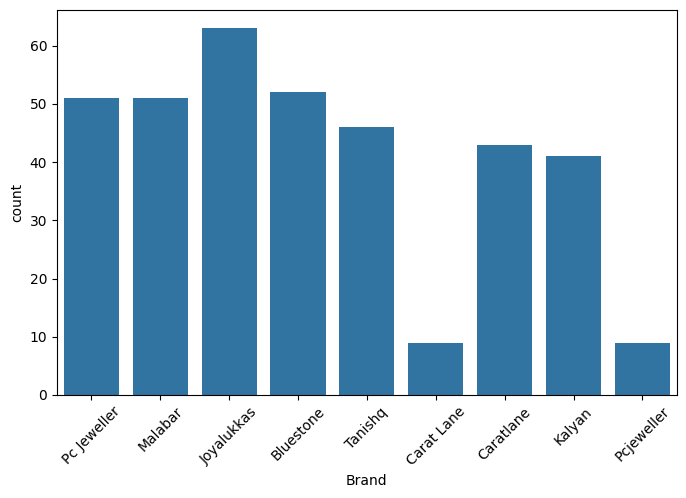

In [47]:
plt.figure(figsize=(8,5))

sns.countplot(x='Brand', data=df)

plt.xticks(rotation=45)

plt.show()

# Insight:
# • This chart highlights the most frequently purchased jewellery brands.
# • Brands with higher bars have stronger customer demand.

# Action:
# • Increase inventory for top-selling brands.
# • Improve visibility of low-performing brands through promotions.

# Visual 2 — Category Distribution

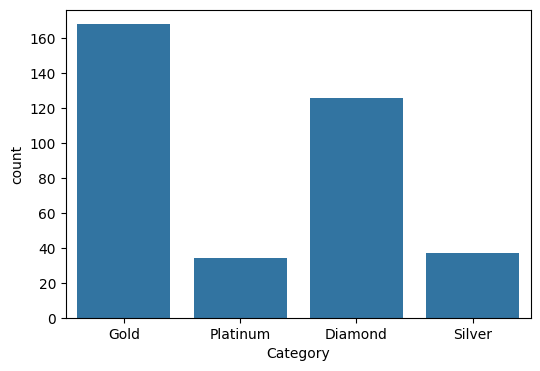

In [48]:
plt.figure(figsize=(6,4))

sns.countplot(x='Category', data=df)

plt.show()

# Insight:
# • The chart shows customer preference across jewellery categories.
# • Popular categories contribute significantly to transaction volume.

# Action:
# • Focus inventory planning on high-demand categories.
# • Introduce offers to boost underperforming categories.

# STEP 8 — Bivariate Analysis

# 8.1 Brand vs Average Rating

In [49]:
df.groupby('Brand')['Rating'].mean().sort_values(ascending=False)

# Insight:
# • Some brands consistently receive higher customer ratings.
# • Higher ratings indicate better customer satisfaction and trust.
# • Top-rated brands are likely delivering superior product quality and service.

# Action:
# • Study best-rated brands and replicate their practices.
# • Improve customer experience for lower-rated brands.
# • Highlight highly-rated brands in marketing campaigns.

Brand
Kalyan         4.297561
Malabar        4.245098
Tanishq        4.139130
Carat Lane     4.111111
Pc Jeweller    4.101961
Caratlane      4.086047
Bluestone      4.032692
Pcjeweller     4.000000
Joyalukkas     3.977778
Name: Rating, dtype: float64

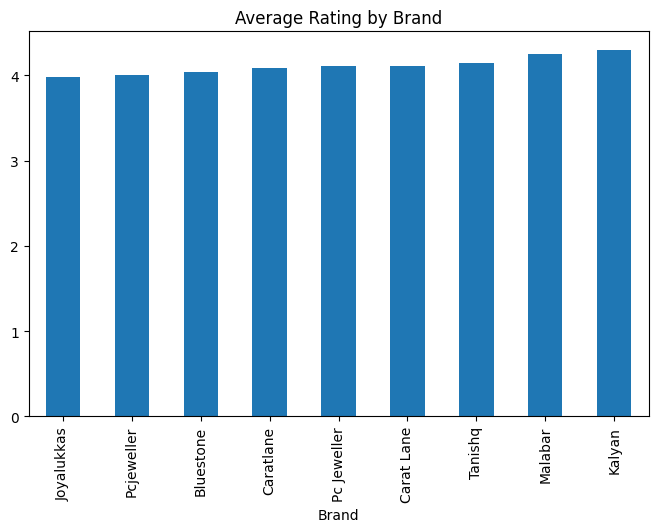

In [50]:
plt.figure(figsize=(8,5))

df.groupby('Brand')['Rating'].mean().sort_values().plot(kind='bar')

plt.title("Average Rating by Brand")

plt.show()

# Insight:
# • The chart clearly shows customer satisfaction differences across brands.
# • Brands with lower ratings may require service or product improvements.

# Action:
# • Investigate causes of low customer ratings.
# • Strengthen after-sales service and product quality.

# 8.2 Brand vs Revenue

In [51]:
df.groupby('Brand')['Final_Price'].sum().sort_values(ascending=False)

# Insight:
# • Revenue contribution differs significantly across brands.
# • Top brands generate the majority of sales revenue.
# • Strong brand reputation often leads to higher customer spending.

# Action:
# • Maintain inventory for high-revenue brands.
# • Create promotional campaigns for lower-performing brands.
# • Analyze customer preferences driving top-brand sales.

Brand
Bluestone      5677184.0
Joyalukkas     5475653.0
Pc Jeweller    5256285.0
Malabar        5109622.0
Tanishq        4816937.0
Kalyan         4049420.0
Caratlane      3818785.0
Carat Lane     1330021.0
Pcjeweller     1075006.0
Name: Final_Price, dtype: float64

plt.figure(figsize=(8,5))

df.groupby('Brand')['Final_Price'].sum().sort_values().plot(kind='bar')

plt.title("Revenue by Brand")

plt.show()

# Insight:
# • Revenue concentration is visible among leading jewellery brands.
# • A few brands may dominate overall business performance.

# Action:
# • Diversify sales across brands to reduce dependency.
# • Improve product visibility for lower-revenue brands.

# 8.3 Category vs Revenue

In [52]:
df.groupby('Category')['Final_Price'].sum().sort_values(ascending=False)

# Insight:
# • Certain jewellery categories generate significantly more revenue.
# • Gold and Diamond products usually contribute the highest sales value.
# • Customer spending patterns vary across categories.

# Action:
# • Prioritize inventory for high-revenue categories.
# • Introduce offers to boost weaker categories.
# • Expand premium product offerings in strong categories.

Category
Diamond     19321610.0
Gold        13708707.0
Platinum     2960389.0
Silver        618207.0
Name: Final_Price, dtype: float64

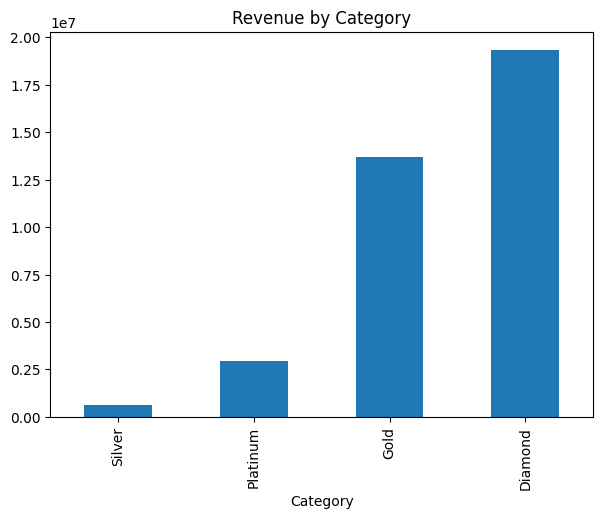

In [53]:
plt.figure(figsize=(7,5))

df.groupby('Category')['Final_Price'].sum().sort_values().plot(kind='bar')

plt.title("Revenue by Category")

plt.show()

# Insight:
# • The chart identifies the most profitable jewellery categories.
# • Revenue is not equally distributed across product types.

# Action:
# • Focus marketing investment on profitable categories.
# • Optimize stock planning using category demand.

# 8.4 Festival vs Revenue

In [54]:
df.groupby('Festival')['Final_Price'].sum().sort_values(ascending=False)

# Insight:
# • Festival seasons contribute heavily to jewellery sales.
# • Certain festivals generate peak customer demand.
# • Seasonal purchasing behaviour is clearly visible.

# Action:
# • Increase inventory before high-performing festivals.
# • Launch festival-specific marketing campaigns.
# • Offer limited-time festive promotions.

Festival
Diwali             10208873.0
Regular Sale        9258523.0
Akshaya Tritiya     8048855.0
Wedding Season      5958383.0
Dhanteras           3134279.0
Name: Final_Price, dtype: float64

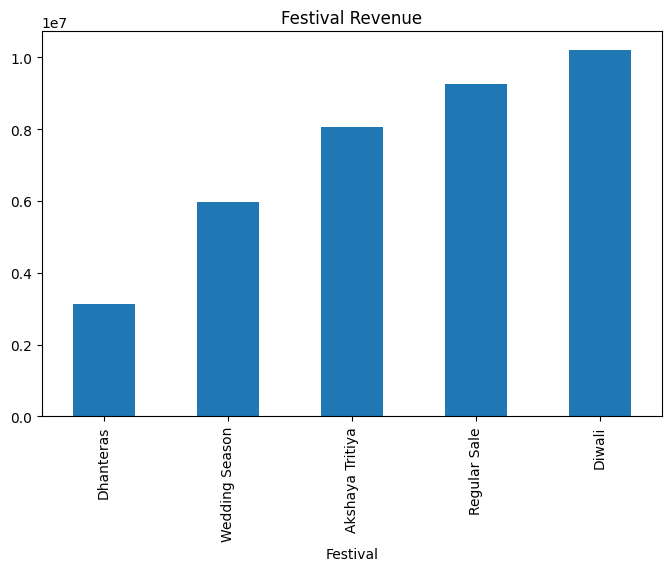

In [55]:
plt.figure(figsize=(8,5))

df.groupby('Festival')['Final_Price'].sum().sort_values().plot(kind='bar')

plt.title("Festival Revenue")

plt.show()

# Insight:
# • Revenue spikes are concentrated around key festive occasions.
# • Festivals play a critical role in annual jewellery sales.

# Action:
# • Allocate additional staff and inventory during peak periods.
# • Plan sales targets around major festivals.

# 8.5 City vs Revenue

In [56]:
df.groupby('City')['Final_Price'].sum().sort_values(ascending=False)

# Insight:
# • Customer spending differs across cities.
# • Some cities contribute significantly more revenue than others.
# • Regional demand patterns can be identified.

# Action:
# • Focus marketing and expansion efforts in top-performing cities.
# • Investigate opportunities in low-performing regions.
# • Customize promotions based on city-level preferences.

City
Mumbai       7400259.0
Pune         6634667.0
Hyderabad    6632437.0
Delhi        5898169.0
Chennai      5242085.0
Bangalore    4801296.0
Name: Final_Price, dtype: float64

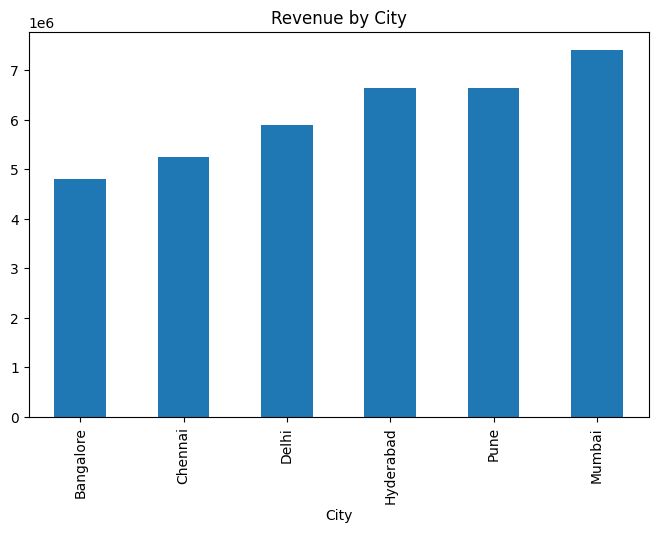

In [57]:
plt.figure(figsize=(8,5))

df.groupby('City')['Final_Price'].sum().sort_values().plot(kind='bar')

plt.title("Revenue by City")

plt.show()

# Insight:
# • Revenue distribution varies across locations.
# • Geographic factors influence jewellery purchasing behaviour.

# Action:
# • Strengthen business presence in high-revenue cities.
# • Develop localized marketing strategies.

# 8.6 Discount vs Rating

In [58]:
df.groupby('Discount_Percent')['Rating'].mean()

# Insight:
# • Customer satisfaction may vary based on discount levels.
# • Discounts can influence perceived purchase value.
# • The relationship helps evaluate promotion effectiveness.

# Action:
# • Identify discount levels that maximize satisfaction.
# • Optimize promotional pricing strategies.
# • Avoid excessive discounts that reduce profitability.

Discount_Percent
0.0     4.082000
5.0     4.104651
8.0     4.156604
10.0    4.134211
12.0    4.102500
15.0    4.200000
18.0    4.080702
20.0    4.052381
Name: Rating, dtype: float64

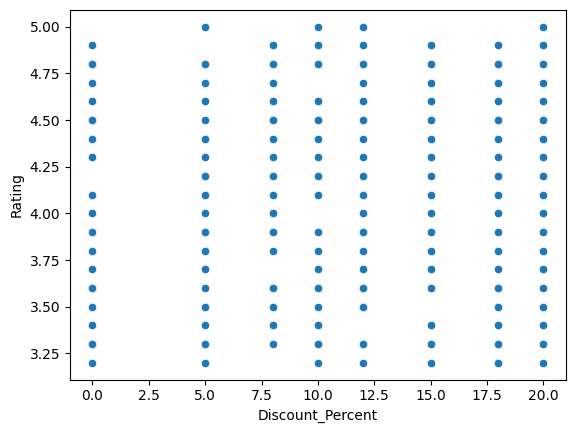

In [59]:
sns.scatterplot(
    x='Discount_Percent',
    y='Rating',
    data=df
)

plt.show()

# Insight:
# • The scatter plot shows whether discounts affect customer ratings.
# • Patterns may reveal customer preference for promotional offers.

# Action:
# • Use insights to design effective discount campaigns.
# • Balance customer satisfaction with profit margins.

# STEP 8 Summary
# Insight:
# • Brand, Category, Festival and City significantly influence jewellery sales performance.
# • Customer ratings vary across brands and promotional strategies.
# • Revenue opportunities are concentrated in specific products and seasons.

# Action:
# • Focus inventory and marketing on high-performing brands and categories.
# • Prepare aggressively for peak festival seasons.
# • Use customer ratings and revenue trends to improve business decisions.

# STEP 9 — GroupBy Analysis, Lambda Functions & Ranking

# 9.1 Brand Performance Summary

In [60]:
df.groupby('Brand').agg({
    'Final_Price':'sum',
    'Rating':'mean',
    'Transaction_ID':'count'
}).sort_values('Final_Price',ascending=False)

# Insight:
# • Some brands generate higher revenue while others achieve higher customer ratings.
# • Strong brands balance both sales performance and customer satisfaction.
# • Brand-wise comparison helps identify market leaders.

# Action:
# • Invest more in high-revenue and highly-rated brands.
# • Improve product quality and service for lower-performing brands.
# • Use top brands as benchmarks for performance improvement.

,Final_Price,Rating,Transaction_ID
Brand,,,
Bluestone,5677184.0,4.032692,52
Joyalukkas,5475653.0,3.977778,63
Pc Jeweller,5256285.0,4.101961,51
Malabar,5109622.0,4.245098,51
Tanishq,4816937.0,4.139130,46
Kalyan,4049420.0,4.297561,41
Caratlane,3818785.0,4.086047,43
Carat Lane,1330021.0,4.111111,9
Pcjeweller,1075006.0,4.000000,9


# 9.2 Category Performance Summary

In [61]:
df.groupby('Category').agg({
    'Final_Price':'sum',
    'Rating':'mean',
    'Transaction_ID':'count'
}).sort_values('Final_Price',ascending=False)

# Insight:
# • Revenue and customer preference differ across jewellery categories.
# • Some categories drive sales volume while others generate premium revenue.
# • Understanding category performance supports inventory planning.

# Action:
# • Prioritize stock for high-performing categories.
# • Promote low-demand categories through targeted offers.
# • Expand premium products in profitable categories.

,Final_Price,Rating,Transaction_ID
Category,,,
Diamond,19321610.0,4.101587,126
Gold,13708707.0,4.102381,168
Platinum,2960389.0,4.214706,34
Silver,618207.0,4.108108,37


# 9.3 Average Revenue Per Transaction By Brand

In [62]:
df.groupby('Brand')['Final_Price'].mean().sort_values(ascending=False)

# Insight:
# • Certain brands attract higher spending customers.
# • Higher average transaction value indicates premium positioning.
# • Customer willingness to spend varies across brands.

# Action:
# • Market premium brands to high-value customers.
# • Create financing and EMI options for expensive jewellery.
# • Develop premium loyalty programs.

Brand
Carat Lane     147780.111111
Pcjeweller     119445.111111
Bluestone      109176.615385
Tanishq        104716.021739
Pc Jeweller    103064.411765
Malabar        100188.666667
Kalyan          98766.341463
Caratlane       88808.953488
Joyalukkas      86915.126984
Name: Final_Price, dtype: float64

# 9.4 Apply Lambda Function

In [63]:
df['Price_Segment'] = df['Final_Price'].apply(
    lambda x: 'Budget'
    if x < 50000
    else 'Premium'
)

df[['Final_Price','Price_Segment']].head()

# Insight:
# • Customers can be segmented into Budget and Premium buyers.
# • Different spending groups have different purchasing behaviour.
# • Segmentation supports targeted marketing.

# Action:
# • Create separate marketing campaigns for each customer segment.
# • Recommend affordable products to budget customers.
# • Promote luxury collections to premium customers.

,Final_Price,Price_Segment
0,36791.0,Budget
1,83490.0,Premium
2,156724.0,Premium
3,6146.0,Budget
4,18487.0,Budget


# 9.5 Count Customers By Segment

In [64]:
df['Price_Segment'].value_counts()

# Insight:
# • The customer base consists of both budget and premium buyers.
# • Understanding segment size helps prioritize business strategy.
# • Revenue opportunities differ across customer groups.

# Action:
# • Allocate inventory according to segment demand.
# • Design personalized offers for each segment.
# • Improve customer retention through targeted engagement.

Price_Segment
Premium    265
Budget     100
Name: count, dtype: int64

# 9.6 Brand Ranking By Revenue

In [65]:
brand_revenue = df.groupby('Brand')['Final_Price'].sum().reset_index()

brand_revenue['Revenue_Rank'] = brand_revenue['Final_Price'].rank(
    ascending=False
)

brand_revenue.sort_values('Revenue_Rank')

# Insight:
# • Revenue ranking identifies the strongest brands in the business.
# • Top-ranked brands contribute significantly to total sales.
# • Ranking simplifies performance comparison.

# Action:
# • Focus marketing investment on top-performing brands.
# • Review pricing and promotions for lower-ranked brands.
# • Track ranking changes over time.

,Brand,Final_Price,Revenue_Rank
0,Bluestone,5677184.0,1.0
3,Joyalukkas,5475653.0,2.0
6,Pc Jeweller,5256285.0,3.0
5,Malabar,5109622.0,4.0
8,Tanishq,4816937.0,5.0
4,Kalyan,4049420.0,6.0
2,Caratlane,3818785.0,7.0
1,Carat Lane,1330021.0,8.0
7,Pcjeweller,1075006.0,9.0


# 9.7 Brand Ranking By Rating

In [66]:
brand_rating = df.groupby('Brand')['Rating'].mean().reset_index()

brand_rating['Rating_Rank'] = brand_rating['Rating'].rank(
    ascending=False
)

brand_rating.sort_values('Rating_Rank')

# Insight:
# • Customer satisfaction varies across brands.
# • Higher-ranked brands enjoy stronger customer trust.
# • Rating rankings reveal customer perception.

# Action:
# • Learn from top-rated brands.
# • Improve customer service for lower-ranked brands.
# • Promote highly-rated products in advertisements.

,Brand,Rating,Rating_Rank
4,Kalyan,4.297561,1.0
5,Malabar,4.245098,2.0
8,Tanishq,4.139130,3.0
1,Carat Lane,4.111111,4.0
6,Pc Jeweller,4.101961,5.0
2,Caratlane,4.086047,6.0
0,Bluestone,4.032692,7.0
7,Pcjeweller,4.000000,8.0
3,Joyalukkas,3.977778,9.0


# 9.8 Best Value Brand Analysis

In [67]:
best_value = df.groupby('Brand').agg({
    'Rating':'mean',
    'Final_Price':'mean'
})

best_value['Value_Score'] = (
    best_value['Rating'] /
    best_value['Final_Price']
) * 10000

best_value.sort_values(
    'Value_Score',
    ascending=False
)

# Insight:
# • Brands with high ratings and lower prices provide better value.
# • Customers can obtain similar satisfaction at lower cost.
# • Best-value brands offer the strongest price-to-quality balance.

# Action:
# • Recommend best-value brands to cost-conscious customers.
# • Highlight value-based products in promotions.
# • Use value analysis to support customer purchase decisions.

,Rating,Final_Price,Value_Score
Brand,,,
Caratlane,4.086047,88808.953488,0.460094
Joyalukkas,3.977778,86915.126984,0.457662
Kalyan,4.297561,98766.341463,0.435124
Malabar,4.245098,100188.666667,0.423710
Pc Jeweller,4.101961,103064.411765,0.398000
Tanishq,4.139130,104716.021739,0.395272
Bluestone,4.032692,109176.615385,0.369373
Pcjeweller,4.000000,119445.111111,0.334882
Carat Lane,4.111111,147780.111111,0.278191


# STEP 10 — Multi-Condition Filtering

# 10.1 Premium Diamond Purchases

In [68]:
df[
    (df['Category']=='Diamond') &
    (df['Final_Price'] > 100000)
]

# Insight:
# • Premium diamond products attract high-spending customers.
# • These transactions contribute significantly to revenue.
# • Luxury jewellery remains an important revenue source.

# Action:
# • Provide personalized service for premium buyers.
# • Offer exclusive memberships and loyalty benefits.
# • Promote luxury collections to affluent customers.

,Transaction_ID,Purchase_Date,Customer_ID,Brand,Category,Product,Festival,City,Quantity,Original_Price,Discount_Percent,Final_Price,Rating,Payment_Mode,Sales_Channel,Return_Status,Making_Charges,Price_Segment
2,TXN0003,2025-06-28,CUST119,Joyalukkas,Diamond,Diamond Earrings,Akshaya Tritiya,Hyderabad,1.0,164973.0,5.0,156724.0,4.3,UPI,Store,No,14145.0,Premium
13,TXN0014,2025-10-17,CUST064,Malabar,Diamond,Diamond Earrings,Regular Sale,Mumbai,1.0,149118.0,18.0,122276.0,3.2,Cash,Store,No,13488.5,Premium
19,TXN0020,2025-08-10,CUST108,Kalyan,Diamond,Diamond Bracelet,Akshaya Tritiya,Mumbai,2.0,331225.0,18.0,271604.0,4.1,Cash,Website,No,21390.0,Premium
20,TXN0021,2025-11-01,CUST098,Joyalukkas,Diamond,Diamond Ring,Akshaya Tritiya,Mumbai,1.0,98811.0,12.0,235014.0,4.1,UPI,Store,No,13488.5,Premium
21,TXN0022,2025-11-07,CUST030,Tanishq,Diamond,Diamond Necklace,Akshaya Tritiya,Pune,1.0,320682.0,12.0,282200.0,4.6,Net Banking,online,No,8957.0,Premium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
355,TXN0356,2025-08-18,CUST005,Carat Lane,Diamond,Diamond Necklace,Diwali,Delhi,1.0,301271.0,10.0,271143.0,4.5,Debit Card,Website,No,19071.0,Premium
357,TXN0358,2025-03-30,CUST042,Kalyan,Diamond,Diamond Earrings,Diwali,Pune,1.0,175349.0,0.0,175349.0,4.8,upi,Offline,Yes,6138.0,Premium
358,TXN0359,2025-06-10,CUST165,Tanishq,Diamond,Diamond Necklace,Regular Sale,Mumbai,1.0,98811.0,5.0,132781.0,4.7,Cash,Store,No,8848.0,Premium
361,TXN0362,2025-07-22,CUST062,Caratlane,Diamond,Diamond Earrings,Diwali,Chennai,1.0,177484.0,0.0,145536.0,3.3,Cash,Store,No,17348.0,Premium


# 10.2 Highly Rated Products

In [69]:
df[
    (df['Rating'] >= 4.5)
]

# Insight:
# • These products deliver strong customer satisfaction.
# • High ratings indicate successful product-market fit.
# • Customer trust is higher for these products.

# Action:
# • Feature highly-rated products on websites and advertisements.
# • Increase inventory for customer favourites.
# • Use customer reviews as marketing assets.

,Transaction_ID,Purchase_Date,Customer_ID,Brand,Category,Product,Festival,City,Quantity,Original_Price,Discount_Percent,Final_Price,Rating,Payment_Mode,Sales_Channel,Return_Status,Making_Charges,Price_Segment
1,TXN0002,2025-08-18,CUST097,Malabar,Platinum,Platinum Chain,Akshaya Tritiya,Mumbai,1.0,188263.0,12.0,83490.0,4.7,Debit Card,Online,No,4309.0,Premium
4,TXN0005,2025-03-07,CUST041,Joyalukkas,Gold,Gold Bangles,Wedding Season,Delhi,1.0,21009.0,12.0,18487.0,4.6,Debit Card,Store,No,17635.0,Budget
8,TXN0009,2025-03-27,CUST105,Joyalukkas,Gold,Gold Ring,Diwali,Delhi,2.0,43666.0,0.0,43666.0,4.9,Cash,Store,Yes,23825.0,Budget
9,TXN0010,2025-12-26,CUST129,Bluestone,Diamond,Diamond Bracelet,Akshaya Tritiya,Hyderabad,1.0,98811.0,0.0,55662.0,4.5,Net Banking,Offline,no,13488.5,Premium
14,TXN0015,2025-04-04,CUST149,Malabar,Gold,Gold Necklace,Regular Sale,Hyderabad,1.0,110050.0,15.0,93542.0,4.9,Credit Card,Store,No,24225.0,Premium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
349,TXN0350,2025-07-22,CUST098,Kalyan,Gold,Gold Ring,Wedding Season,Bangalore,1.0,111187.0,12.0,97844.0,4.9,Credit Card,online,No,15218.0,Premium
354,TXN0355,2025-09-11,CUST033,Malabar,Diamond,Diamond Necklace,Diwali,Mumbai,1.0,275836.0,18.0,226185.0,4.9,upi,Offline,Yes,14718.0,Premium
355,TXN0356,2025-08-18,CUST005,Carat Lane,Diamond,Diamond Necklace,Diwali,Delhi,1.0,301271.0,10.0,271143.0,4.5,Debit Card,Website,No,19071.0,Premium
357,TXN0358,2025-03-30,CUST042,Kalyan,Diamond,Diamond Earrings,Diwali,Pune,1.0,175349.0,0.0,175349.0,4.8,upi,Offline,Yes,6138.0,Premium


# 10.3 Festival OR Premium Purchases

In [70]:
df[
    (df['Festival']=='Diwali') |
    (df['Final_Price'] > 150000)
]

# Insight:
# • Festival shoppers and premium buyers represent valuable customer groups.
# • These segments contribute significantly to overall revenue.
# • Seasonal and luxury demand create major sales opportunities.

# Action:
# • Launch targeted festival campaigns.
# • Provide exclusive offers for premium customers.
# • Build customer retention strategies for high-value buyers.

,Transaction_ID,Purchase_Date,Customer_ID,Brand,Category,Product,Festival,City,Quantity,Original_Price,Discount_Percent,Final_Price,Rating,Payment_Mode,Sales_Channel,Return_Status,Making_Charges,Price_Segment
0,TXN0001,2025-04-30,CUST155,Pc Jeweller,Gold,Gold Necklace,Diwali,Chennai,1.0,44868.0,18.0,36791.0,3.3,Credit Card,online,Yes,12149.0,Budget
2,TXN0003,2025-06-28,CUST119,Joyalukkas,Diamond,Diamond Earrings,Akshaya Tritiya,Hyderabad,1.0,164973.0,5.0,156724.0,4.3,UPI,Store,No,14145.0,Premium
8,TXN0009,2025-03-27,CUST105,Joyalukkas,Gold,Gold Ring,Diwali,Delhi,2.0,43666.0,0.0,43666.0,4.9,Cash,Store,Yes,23825.0,Budget
11,TXN0012,2025-01-29,CUST035,Malabar,Gold,Gold Chain,Diwali,Delhi,1.0,97303.0,0.0,97303.0,4.4,Cash,Store,no,17008.0,Premium
19,TXN0020,2025-08-10,CUST108,Kalyan,Diamond,Diamond Bracelet,Akshaya Tritiya,Mumbai,2.0,331225.0,18.0,271604.0,4.1,Cash,Website,No,21390.0,Premium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
360,TXN0361,2025-05-18,CUST075,Pc Jeweller,Diamond,Diamond Earrings,Diwali,Pune,1.0,77954.0,0.0,77954.0,4.3,upi,Offline,no,17918.0,Premium
361,TXN0362,2025-07-22,CUST062,Caratlane,Diamond,Diamond Earrings,Diwali,Chennai,1.0,177484.0,0.0,145536.0,3.3,Cash,Store,No,17348.0,Premium
362,TXN0363,2025-03-10,CUST066,Kalyan,Gold,Gold Necklace,Akshaya Tritiya,Hyderabad,1.0,169129.0,5.0,160672.0,3.5,upi,Offline,Yes,13017.0,Premium
363,TXN0364,2025-05-06,CUST144,Caratlane,Platinum,Platinum Chain,Akshaya Tritiya,Mumbai,1.0,208927.0,0.0,208927.0,4.3,UPI,Store,Yes,16351.0,Premium


# STEP 9 & 10 Summary

# Insight:
# • Brand performance varies across revenue, ratings and value scores.
# • Customer segments, rankings and filtering reveal important business patterns.
# • Certain brands provide better value while others dominate premium sales.

# Action:
# • Focus on high-performing brands and customer segments.
# • Promote best-value products to increase customer satisfaction.
# • Use rankings and filtering insights to drive marketing and inventory decisions.

# 11.1 Top Revenue Generating Brands

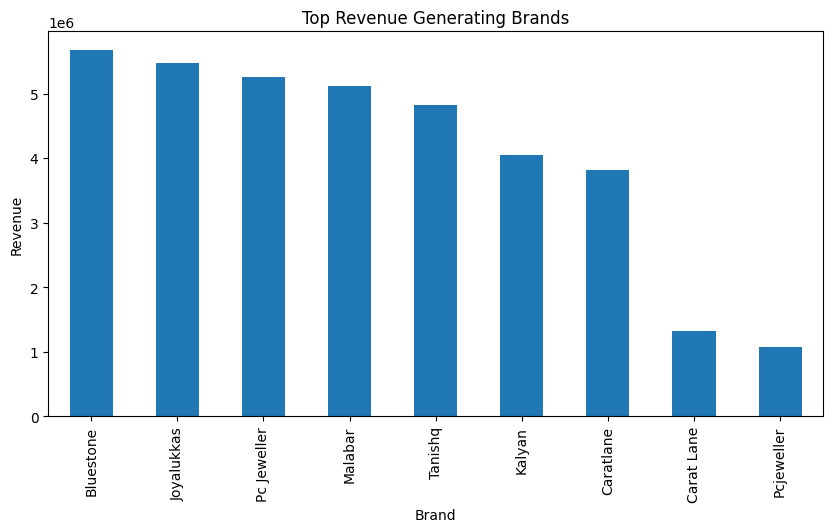

In [71]:
plt.figure(figsize=(10,5))

df.groupby('Brand')['Final_Price'].sum()\
.sort_values(ascending=False)\
.plot(kind='bar')

plt.title("Top Revenue Generating Brands")
plt.xlabel("Brand")
plt.ylabel("Revenue")

plt.show()

# Insight:
# • Some brands contribute significantly more revenue than others.
# • Revenue is concentrated among a few leading jewellery brands.
# • Brand popularity strongly impacts sales performance.

# Action:
# • Increase inventory for top revenue-generating brands.
# • Improve visibility of low-performing brands through promotions.
# • Focus marketing budget on high-demand brands.

# 11.2 Average Rating By Brand

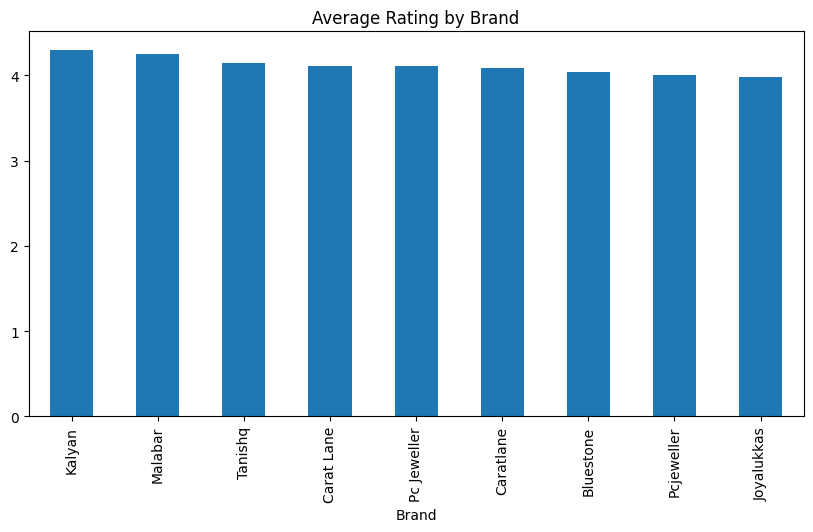

In [72]:
plt.figure(figsize=(10,5))

df.groupby('Brand')['Rating'].mean()\
.sort_values(ascending=False)\
.plot(kind='bar')

plt.title("Average Rating by Brand")

plt.show()

# Insight:
# • Customer satisfaction varies across brands.
# • Higher-rated brands are trusted more by customers.
# • Ratings influence future purchase decisions.

# Action:
# • Promote highly-rated brands.
# • Improve service quality for lower-rated brands.
# • Monitor customer feedback regularly.

# 11.3 Revenue By Category

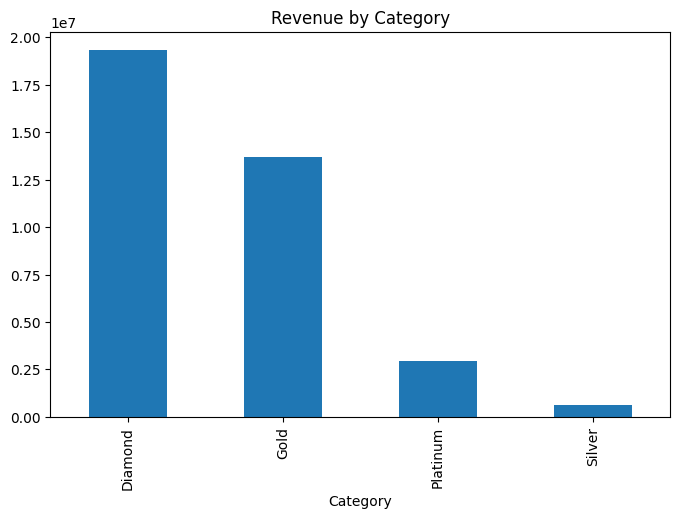

In [73]:
plt.figure(figsize=(8,5))

df.groupby('Category')['Final_Price'].sum()\
.sort_values(ascending=False)\
.plot(kind='bar')

plt.title("Revenue by Category")

plt.show()

# Insight:
# • Gold and Diamond categories contribute the majority of revenue.
# • Premium jewellery categories dominate customer spending.
# • Revenue contribution differs significantly across categories.

# Action:
# • Prioritize inventory for high-revenue categories.
# • Launch category-specific promotional campaigns.
# • Introduce premium collections in high-demand segments.

# 11.4 Festival Revenue Analysis

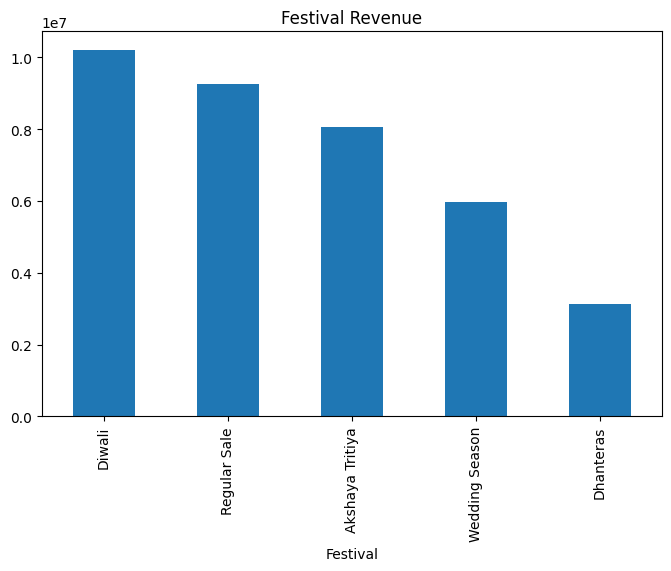

In [74]:
plt.figure(figsize=(8,5))

df.groupby('Festival')['Final_Price'].sum()\
.sort_values(ascending=False)\
.plot(kind='bar')

plt.title("Festival Revenue")

plt.show()

# Insight:
# • Festival seasons drive major jewellery purchases.
# • Certain festivals contribute significantly more revenue.
# • Customer buying behaviour increases during celebrations.

# Action:
# • Increase stock before major festivals.
# • Launch festive offers and marketing campaigns.
# • Prepare staffing and inventory for seasonal demand.

# 11.5 Correlation Heatmap

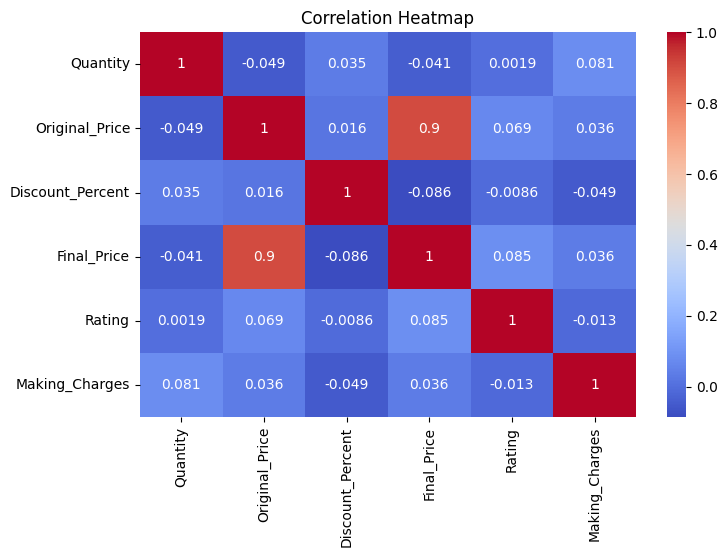

In [75]:
plt.figure(figsize=(8,5))

sns.heatmap(
    df[['Quantity',
        'Original_Price',
        'Discount_Percent',
        'Final_Price',
        'Rating',
        'Making_Charges']].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

# Insight:
# • The heatmap reveals relationships between pricing,
#   discounts, quantity and customer ratings.
# • Strong positive correlations indicate variables that move together.
# • Weak correlations suggest limited business impact.

# Action:
# • Focus on factors that strongly influence customer purchases.
# • Use pricing and discount relationships to optimize revenue.
# • Support decision-making with data-driven strategies.

# 11.6 Best Value Brand Visualization

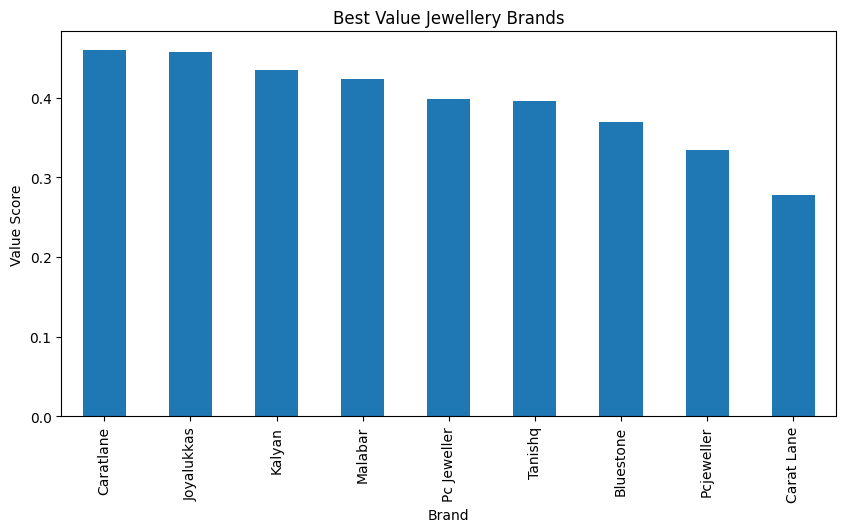

In [76]:
best_value = df.groupby('Brand').agg({
    'Rating':'mean',
    'Final_Price':'mean'
})

best_value['Value_Score'] = (
    best_value['Rating']
    /
    best_value['Final_Price']
) * 10000

best_value = best_value.sort_values(
    'Value_Score',
    ascending=False
)

plt.figure(figsize=(10,5))

best_value['Value_Score'].plot(kind='bar')

plt.title("Best Value Jewellery Brands")

plt.ylabel("Value Score")

plt.show()

# Insight:
# • Brands with higher value scores provide better quality at lower prices.
# • Customers can achieve similar satisfaction while spending less.
# • Certain brands offer stronger value-for-money propositions.

# Action:
# • Recommend best-value brands to budget-conscious customers.
# • Highlight these brands in marketing campaigns.
# • Help customers make cost-effective purchase decisions.

# STEP 12 — Final Business Insights & Conclusion

# FINAL BUSINESS INSIGHTS

# • Gold and Diamond categories generated the highest customer demand and revenue.
#
# • Festival periods such as Diwali and Akshaya Tritiya
#   significantly increased jewellery purchases.
#
# • Brand performance varied across revenue,
#   customer ratings and value scores.
#
# • Some brands delivered strong customer satisfaction
#   at comparatively lower prices.
#
# • Best-value brands demonstrated the ideal balance
#   between affordability and quality.
#
# • Customers choosing these brands could potentially
#   save up to approximately 15–20% while maintaining
#   similar satisfaction levels.

# FINAL RECOMMENDATIONS

# RECOMMENDATIONS

# • Focus inventory planning on Gold and Diamond categories.
#
# • Increase marketing efforts before major festivals.
#
# • Promote highly-rated and best-value brands.
#
# • Improve service quality for lower-rated brands.
#
# • Use customer ratings and purchase patterns
#   to guide future pricing and product strategies.

# Project Conclusion

# CONCLUSION

# This analysis examined 300+ jewellery purchase transactions
# across multiple brands, categories and festival seasons.
#
# Data cleaning, EDA, visualization, groupby analysis,
# lambda functions, ranking and filtering techniques
# were applied to uncover customer purchase behaviour.
#
# The analysis identified top-performing brands,
# revenue-driving categories and best-value jewellery options,
# helping customers make smarter purchase decisions
# while enabling businesses to improve sales strategies.